# BayeSN SNIa

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.pzflow_node import PZFlowNode
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    HostmassX1Func,
    X0FromDistMod,
)
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.models.bayesn import BayesnModel
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.models.snia_host import SNIaHost
from lightcurvelynx.utils.plotting import plot_lightcurves

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR

## Load Data Files

We start by loading the files we will need for running the simulation: the OpSim database and the passband information. Both of these live in the `data/` directory in the root directory. Note that nothing in this directory is saved to github, so the files might have to be downloaded initially.

In [2]:
# Load the OpSim data.
opsim_db = OpSim.from_url(
    "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs5.3/baseline/baseline_v5.3.0_10yrs.db",
)
t_min, t_max = opsim_db.time_bounds()
print(f"Loaded OpSim with {len(opsim_db)} rows and times [{t_min}, {t_max}]")

# Load the passband data for the griz filters only.
passband_group = PassbandGroup.from_preset(
    preset="LSST",
    filters=["g", "r", "i", "z"],
    trim_quantile=0.001,
    delta_wave=1,
)
# passband_group = PassbandGroup.from_preset(preset="LSST", table_dir=table_dir)
print(f"Loaded Passbands: {passband_group}")

Loaded OpSim with 1844571 rows and times [61208.201382236985, 64860.44487408427]
Loaded Passbands: PassbandGroup containing 4 passbands: LSST_g, LSST_r, LSST_i, LSST_z


In [3]:
# Create a mask of matching filters.
filter_mask = passband_group.mask_by_filter(opsim_db["filter"])

# Filter the OpSim
opsim_db = opsim_db.filter_rows(filter_mask)
t_min, t_max = opsim_db.time_bounds()
print(f"Filtered OpSim to {len(opsim_db)} rows and times [{t_min}, {t_max}]")

Filtered OpSim to 1421879 rows and times [61208.42731204634, 64860.44487408427]


## Create the model

To generate simulationed light curves we need to define the proporties of the object from which to sample. We start by creating a host based on a pre-trained pzflow model.

In [4]:
# Load the Flow model into a PZFlow node. This gives access to all of the outputs of the
# flow model as attributes of the PZFlowNode.
pz_node = PZFlowNode.from_file(
    _LIGHTCURVELYNX_BASE_DATA_DIR / "model_files" / "snia_hosts_test_pzflow.pkl",  # filename
    node_label="pznode",
)

# Create a model for the host of the SNIa. The attributes will be sampled via
# the PZFlowNode's model. So each host instantiation will have its own properties.
# Note: This requires the user to know the output names from the underlying flow model.
host = SNIaHost(
    ra=pz_node.RA_GAL,
    dec=pz_node.DEC_GAL,
    hostmass=pz_node.LOGMASS,
    redshift=NumpyRandomFunc("uniform", low=0.1, high=0.6),
    node_label="host",
)

Here we define the Amplitude class with the purpose to create the distance modulus normalization factor to be added as a parameter to the bayesn model.

In [5]:
from lightcurvelynx.base_models import FunctionNode


class AmplitudeFromDistMod(FunctionNode):
    def __init__(self, distmod, m_abs, **kwargs):
        # Call the super class's constructor with the needed information.
        super().__init__(
            func=self._amplitude_given_distmod,
            distmod=distmod,
            m_abs=m_abs,
            **kwargs,
        )

    def _amplitude_given_distmod(self, distmod, m_abs):
        """Compute distance modulus given redshift and cosmology.

        Parameters
        ----------
        distmod: float or numpy.ndarray
            The distance modulus (in mag)
        m_abs: float or numpy.ndarry
            The absolute magnitude modulus (in mag)

        Returns
        -------
        amplitude : float or numpy.ndarray
            The distance modulus effect
        """
        return np.power(10.0, -0.4 * (distmod + m_abs))

Next we create the SNIa model itself. We use bayeSN model with parameters randomly generated from realistic distributions.

Note that some attributes, such as (RA, dec), are sampled relative to the host's properties.

In [6]:
bayesian_model_name = "bayesnModel"
distmod_func = DistModFromRedshift(host.redshift, H0=73.0, Omega_m=0.3)
m_abs_func = NumpyRandomFunc("normal", loc=-19.3, scale=0.1)
amplitude_func = AmplitudeFromDistMod(distmod_func, m_abs_func)
source = BayesnModel(
    theta=NumpyRandomFunc("uniform", low=-1.74, high=2.10),
    Av=NumpyRandomFunc("uniform", low=0.01, high=0.3),
    Rv=NumpyRandomFunc("uniform", low=3, high=3),
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    ra=NumpyRandomFunc("normal", loc=host.ra, scale=0.01),
    dec=NumpyRandomFunc("normal", loc=host.dec, scale=0.01),
    redshift=host.redshift,
    node_label="source",
    Amplitude=amplitude_func,
)

## Generate the simulations

We can now generate random simulations with all the information defined above. The light curves are written in the [nested-pandas](https://github.com/lincc-frameworks/nested-pandas) format for easy analysis. 

In [7]:
lightcurves = simulate_lightcurves(source, 10, opsim_db, passband_group)
lightcurves

/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/simulate.py:681: FutureWarning: The passbands argument is deprecated and will be removed from future versions.
  warnings.warn(
/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/simulate.py:693: FutureWarning: Passing ObsTable objects directly in survey_info is deprecated and will be removed in future versions. Please use SurveyInfo objects instead.
  warnings.warn(
Simulating:   0%|          | 0/10 [00:00<?, ?obj/s]/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/models/physical_model.py:535: UserWarning: Some times are less than the model's defined bounds and no time extrapolation is set. If this is not the intended, you can enable time extrapolation using the 'time_extrapolation' parameter.
  warnings.warn(
/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/models/physical_model.py:562: UserWarning: Some times are greater than the model's defined bounds and no time extrapolation

id         ra        dec  nobs            t0         z  \
0   0  55.111606 -43.296565   549  62957.545979  0.320502   
1   1  55.219284 -43.244418   539  61574.163160  0.551773   
2   2  55.088449 -43.345668   539  62269.021227  0.583010   
3   3  55.230072 -43.220142   543  61316.687771  0.550559   
4   4  55.290707 -43.268526   535  63254.178985  0.434742   
5   5  55.237387 -43.228950   546  62620.875108  0.116190   
6   6  55.179483 -43.329283   534  64086.463389  0.156800   
7   7  55.244709 -43.314212   547  62303.896138  0.141426   
8   8  55.160625 -43.345003   534  63935.107058  0.531085   
9   9  55.158439 -43.270305   543  61993.714382  0.302368   

                                          lightcurve  \
0  [{mjd: 61298.39201, filter: 'z', flux: 93.0356...   
1  [{mjd: 61298.39201, filter: 'z', flux: -239.64...   
2  [{mjd: 61298.39201, filter: 'z', flux: -583.96...   
3  [{mjd: 61298.39201, filter: 'z', flux: 411.736...   
4  [{mjd: 61298.39201, filter: 'z', flux: -100.14...   
5  [{mjd: 61298.39201, filter: 'z', flux: 305.635...   
6  [{mjd: 61298.39201, filter: 'z', flux: 141.615...   
7  [{mjd: 61298.39201, filter: 'z', flux: -648.89...   
8  [{mjd: 61298.39201, filter: 'z', flux: -180.63...   
9  [{mjd: 61298.39201, filter: 'z', flux: -63.529...   

                                              params  
0  {'pznode.RA_GAL': 55.118370056152344, 'pznode....  
1  {'pznode.RA_GAL': 55.21249008178711, 'pznode.D...  
2  {'pznode.RA_GAL': 55.085205078125, 'pznode.DEC...  
3  {'pznode.RA_GAL': 55.23284149169922, 'pznode.D...  
4  {'pznode.RA_GAL': 55.300758361816406, 'pznode....  
5  {'pznode.RA_GAL': 55.2384147644043, 'pznode.DE...  
6  {'pznode.RA_GAL': 55.18138122558594, 'pznode.D...  
7  {'pznode.RA_GAL': 55.24802017211914, 'pznode.D...  
8  {'pznode.RA_GAL': 55.14934158325195, 'pznode.D...  
9  {'pznode.RA_GAL': 55.16922378540039, 'pznode.D...

Now let's plot some random light curves

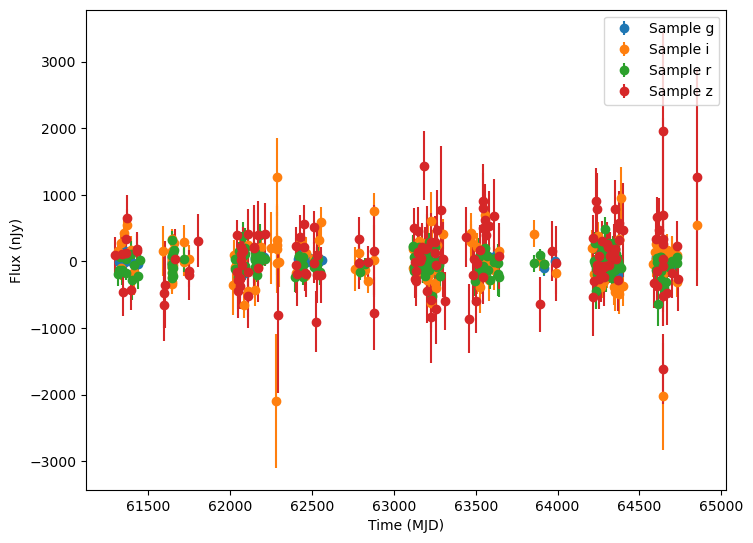

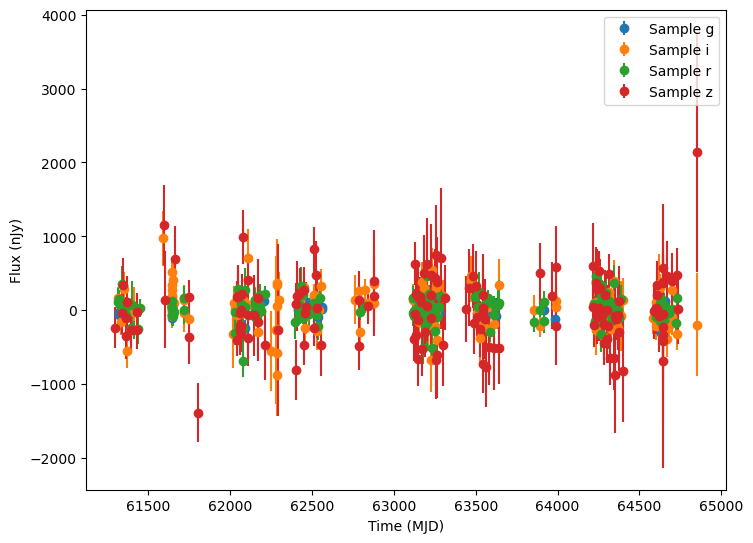

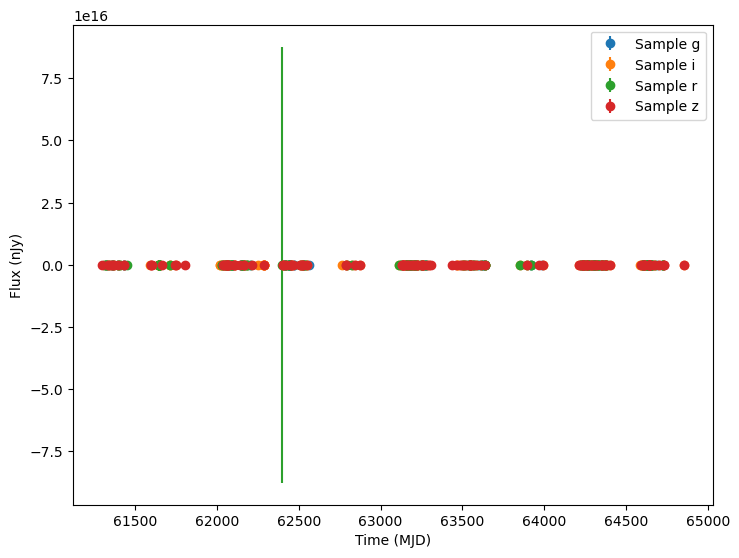

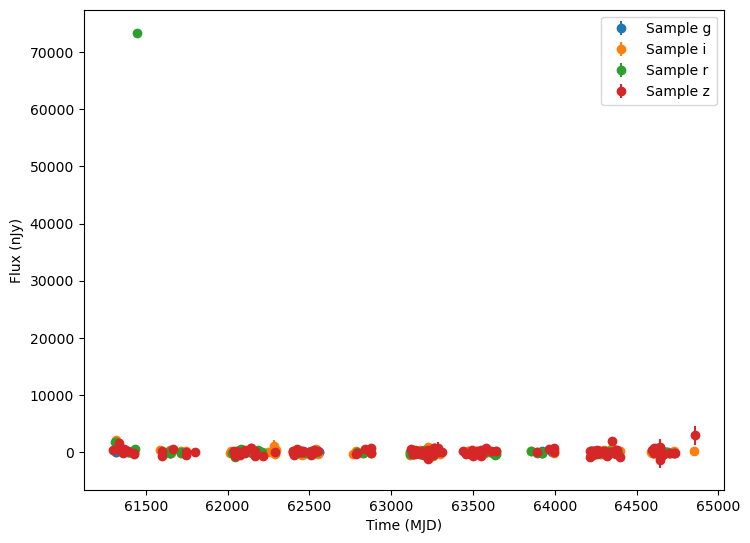

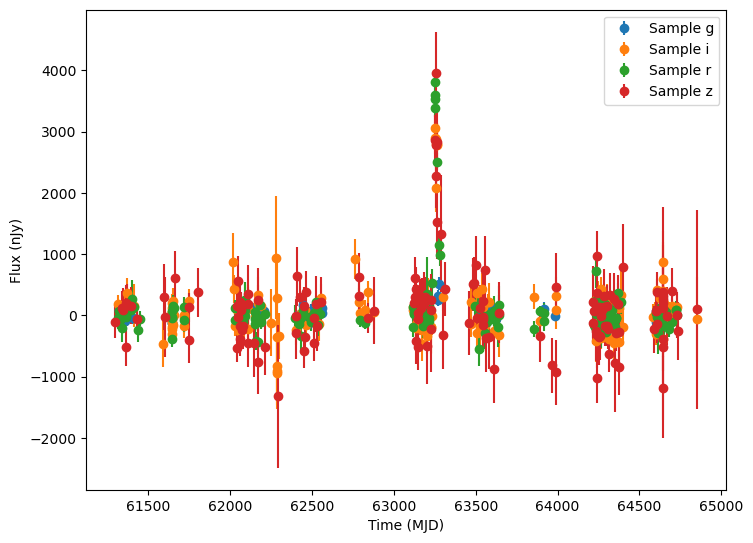

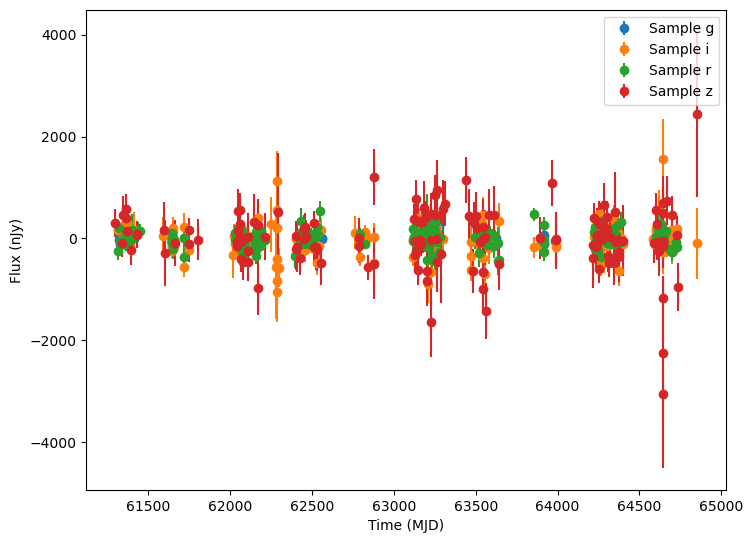

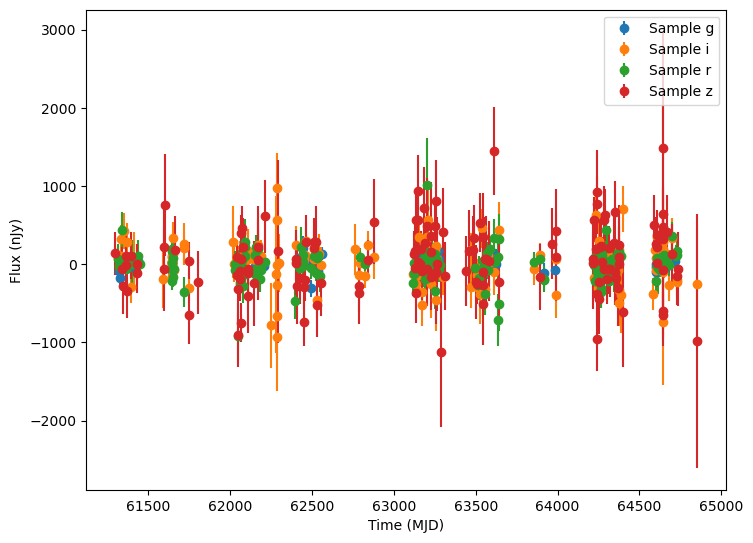

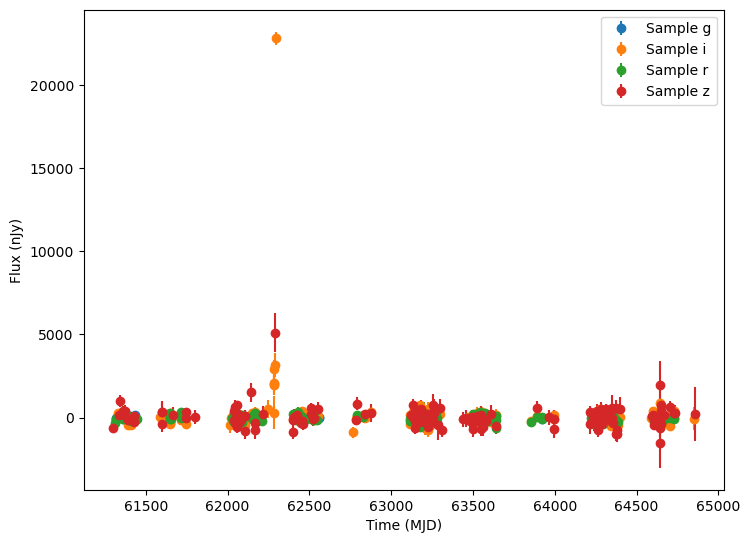

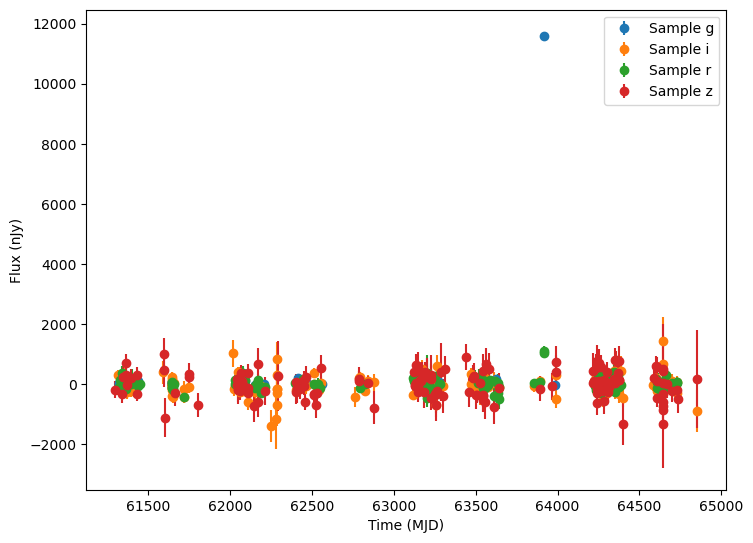

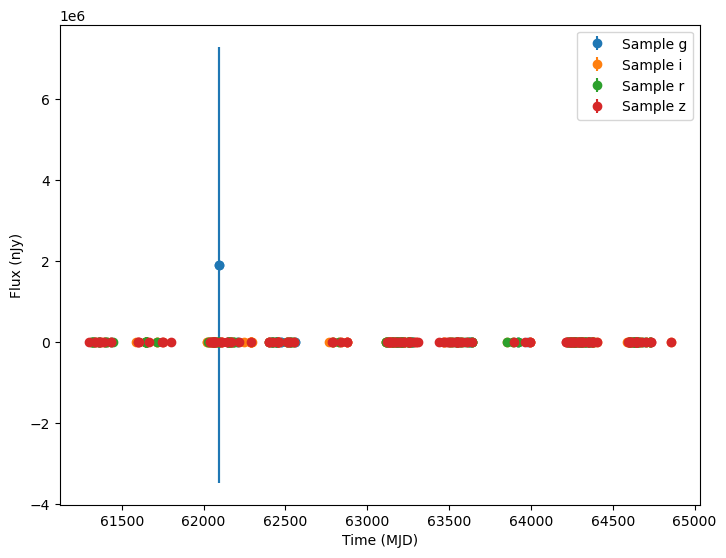

In [8]:
for idx in range(len(lightcurves)):
    # Extract the row for this object.
    lc = lightcurves.loc[idx]

    if lc["nobs"] > 0:
        # Unpack the nested columns (filters, mjd, flux, and flux error).
        lc_filters = np.asarray(lc["lightcurve"]["filter"], dtype=str)
        lc_mjd = np.asarray(lc["lightcurve"]["mjd"], dtype=float)
        lc_flux = np.asarray(lc["lightcurve"]["flux"], dtype=float)
        lc_fluxerr = np.asarray(lc["lightcurve"]["fluxerr"], dtype=float)

        plot_lightcurves(
            fluxes=lc_flux,
            times=lc_mjd,
            fluxerrs=lc_fluxerr,
            filters=lc_filters,
        )

We can also plot the light curves in magnitude

/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_20913/2879962121.py:1: RuntimeWarning: invalid value encountered in log10
  lc_mag = -2.5 * np.log10(lc_flux) + 31.4


(23.947033074795897, 22.32642668858416)

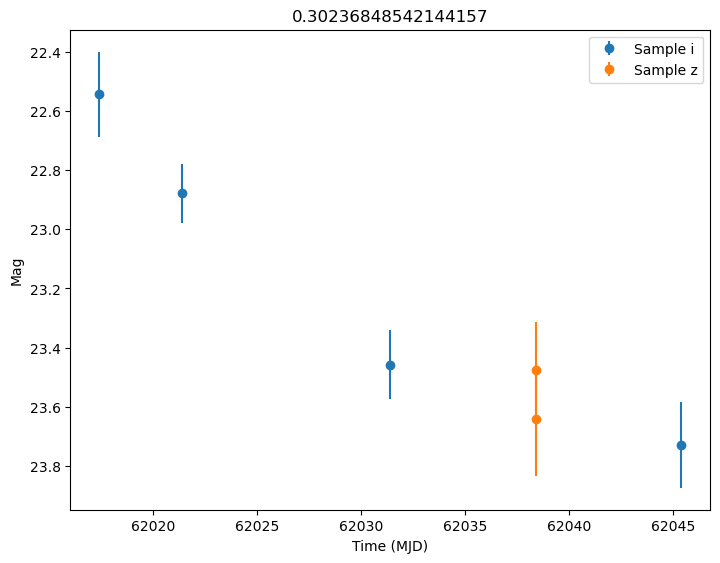

In [11]:
lc_mag = -2.5 * np.log10(lc_flux) + 31.4
lc_magerr = np.absolute(1.086 * lc_fluxerr / lc_flux)

det = lc_magerr < 0.2
plot_lightcurves(
    fluxes=lc_mag[det],
    times=lc_mjd[det],
    fluxerrs=lc_magerr[det],
    filters=lc_filters[det],
)
plt.title(lc["z"])
plt.ylabel("Mag")
plt.ylim(plt.ylim()[::-1])